# 7. Model Inference (Pengujian Model Tunggal)
Notebook ini difokuskan untuk melakukan prediksi pada satu gambar rontgen baru (*unseen data*). Fungsi di sini mensimulasikan penggunaan AI di dunia nyata sebelum diintegrasikan ke dalam sistem Web.

In [15]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image
from tensorflow.keras.models import load_model
import os

# 1. Load Model
model_path = '../models/resnet50_best_model.h5'
print("Memuat model...")
model = load_model(model_path)
class_names = ['COVID', 'Normal', 'Viral_Pneumonia']
print("Model siap digunakan!")

# 2. Fungsi Inference
def diagnosis_paru(path_gambar):
    # Pra-pemrosesan
    img = image.load_img(path_gambar, target_size=(224, 224))
    img_array = image.img_to_array(img)
    img_array = img_array / 255.0  
    img_batch = np.expand_dims(img_array, axis=0) 
    
    # Prediksi
    prediction = model.predict(img_batch, verbose=0)
    predicted_class_idx = np.argmax(prediction)
    predicted_label = class_names[predicted_class_idx]
    confidence = np.max(prediction) * 100
  
    if predicted_label == "Normal":
        warna = "green"
        teks_status = "Paru Normal"
    else:
        warna = "red"
        teks_status = "Terdeteksi Penyakit Paru"
    
    # Visualisasi
    plt.figure(figsize=(5, 5))
    plt.imshow(img)
    plt.axis('off')
    
    # Menampilkan Teks Status utama, diikuti Diagnosis rincinya
    plt.title(f"Status: {teks_status}\nDiagnosis Rinci: {predicted_label}\nKeyakinan: {confidence:.2f}%", 
              fontsize=12, fontweight='bold', color=warna)
    plt.show()
    
    return predicted_label, confidence

Memuat model...


Model siap digunakan!


Membuka File Manager... Silakan pilih gambar rontgen pasien.
File berhasil diunggah dari: D:/lung-disease-classification-resnet50/dataset/processed/val/Normal/Normal-7.png



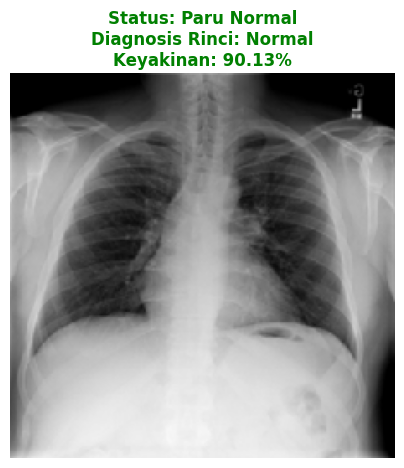

LOG SISTEM: Diagnosis selesai. Hasil siap diteruskan ke database web.


In [16]:
import tkinter as tk
from tkinter import filedialog
import os

# 1. Membuat jendela utama rahasia
root = tk.Tk()
root.withdraw()
root.attributes('-topmost', True) 

print("Membuka File Manager... Silakan pilih gambar rontgen pasien.")

# 2. Membuka File Manager secara pop-up
path_gambar_terpilih = filedialog.askopenfilename(
    title="Upload Gambar X-Ray Paru-Paru",
    filetypes=[("Image files", "*.png *.jpg *.jpeg")]
)

root.destroy()

# 3. Mengeksekusi prediksi jika gambar berhasil dipilih
if path_gambar_terpilih:
    print(f"File berhasil diunggah dari: {path_gambar_terpilih}\n")
    
    hasil_diagnosis, persentase = diagnosis_paru(path_gambar_terpilih)
    
    print(f"LOG SISTEM: Diagnosis selesai. Hasil siap diteruskan ke database web.")
else:
    print("Upload dibatalkan. Tidak ada gambar yang dipilih.")